# Tilt Angle Analysis: Launch to Apogee

This notebook estimates the rocket tilt angle during ascent using the Blue Raven high-rate quaternion data.

Tilt is defined here as the angle between:
- the rocket longitudinal axis at launch, and
- the rocket longitudinal axis at each later sample.

Assumption used in this workspace: the rocket longitudinal axis is the body `+X` axis in the HR data. That assumption is checked against the flight summary by comparing the computed tilt at burnout to the reported burnout tilt.

In [40]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from path_config import default_hr_csv, default_summary_csv

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 3)

BODY_AXIS = np.array([1.0, 0.0, 0.0])

hr_csv_path = default_hr_csv()
summary_csv_path = default_summary_csv()

print(f"HR CSV: {hr_csv_path}")
print(f"Summary CSV: {summary_csv_path}")

HR CSV: C:\Users\lamor\OneDrive\src\DataAnalysisSnowbirdTest\exports\SnowbirdPrim HR_03-21-2026_10_52_17.csv
Summary CSV: C:\Users\lamor\OneDrive\src\DataAnalysisSnowbirdTest\exports\SnowbirdPrim_summary_03-21-2026_10_52_17_.csv


In [41]:
def read_summary_pairs(summary_path: Path | None) -> dict[str, str]:
    if summary_path is None or not Path(summary_path).exists():
        return {}

    summary_pairs: dict[str, str] = {}
    with open(summary_path, "r", encoding="utf-8-sig") as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line or "," not in line:
                continue
            metric, value = line.split(",", 1)
            summary_pairs[metric.strip()] = value.strip()

    return summary_pairs


def parse_summary_float(summary_pairs: dict[str, str], key: str) -> float:
    raw = summary_pairs.get(key)
    if raw is None:
        return np.nan
    token = str(raw).split()[0].replace(",", "")
    try:
        return float(token)
    except ValueError:
        return np.nan


def quat_to_matrix(w: float, x: float, y: float, z: float) -> np.ndarray:
    quat = np.array([w, x, y, z], dtype=float)
    norm = np.linalg.norm(quat)
    if not np.isfinite(norm) or norm == 0.0:
        return np.eye(3)

    w, x, y, z = quat / norm
    return np.array(
        [
            [1.0 - 2.0 * (y * y + z * z), 2.0 * (x * y - z * w), 2.0 * (x * z + y * w)],
            [2.0 * (x * y + z * w), 1.0 - 2.0 * (x * x + z * z), 2.0 * (y * z - x * w)],
            [2.0 * (x * z - y * w), 2.0 * (y * z + x * w), 1.0 - 2.0 * (x * x + y * y)],
        ]
    )


def angle_between_deg(vector_a: np.ndarray, vector_b: np.ndarray) -> float:
    vector_a = np.asarray(vector_a, dtype=float)
    vector_b = np.asarray(vector_b, dtype=float)
    denom = np.linalg.norm(vector_a) * np.linalg.norm(vector_b)
    if not np.isfinite(denom) or denom == 0.0:
        return np.nan
    cosine = np.clip(np.dot(vector_a, vector_b) / denom, -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine)))

In [42]:
summary_pairs = read_summary_pairs(summary_csv_path)
apogee_time_s = parse_summary_float(summary_pairs, "Time to Apo channel fire")
burnout_time_s = parse_summary_float(summary_pairs, "Time to first burnout")
reported_burnout_tilt_deg = parse_summary_float(summary_pairs, "Tilt angle at burnout")

hr = pd.read_csv(hr_csv_path, low_memory=False)
hr.columns = [str(col).strip() for col in hr.columns]

numeric_columns = ["Flight_Time_(s)", "Quat_1", "Quat_2", "Quat_3", "Quat_4"]
for column in numeric_columns:
    hr[column] = pd.to_numeric(hr[column], errors="coerce")

flight = (
    hr.dropna(subset=numeric_columns)
      .sort_values("Flight_Time_(s)")
      .loc[lambda df: df["Flight_Time_(s)"] >= 0.0]
      .reset_index(drop=True)
      .copy()
)

launch_index = int((flight["Flight_Time_(s)"] - 0.0).abs().idxmin())
launch_quat = flight.loc[launch_index, ["Quat_1", "Quat_2", "Quat_3", "Quat_4"]].to_numpy(dtype=float)
launch_axis = quat_to_matrix(*launch_quat) @ BODY_AXIS
launch_axis = launch_axis / np.linalg.norm(launch_axis)

quat_values = flight[["Quat_1", "Quat_2", "Quat_3", "Quat_4"]].to_numpy(dtype=float)
rocket_axis_vectors = np.vstack([quat_to_matrix(*quat) @ BODY_AXIS for quat in quat_values])
rocket_axis_vectors = rocket_axis_vectors / np.linalg.norm(rocket_axis_vectors, axis=1, keepdims=True)

flight["tilt_angle_deg"] = [angle_between_deg(axis, launch_axis) for axis in rocket_axis_vectors]

ascent = flight.loc[flight["Flight_Time_(s)"] <= apogee_time_s].copy()

burnout_index = int((ascent["Flight_Time_(s)"] - burnout_time_s).abs().idxmin())
computed_burnout_tilt_deg = float(ascent.loc[burnout_index, "tilt_angle_deg"])

validation_error_deg = computed_burnout_tilt_deg - reported_burnout_tilt_deg

summary_table = pd.DataFrame(
    [
        {"metric": "Apogee time (s)", "value": apogee_time_s},
        {"metric": "Burnout time (s)", "value": burnout_time_s},
        {"metric": "Computed tilt at burnout (deg)", "value": computed_burnout_tilt_deg},
        {"metric": "Reported tilt at burnout (deg)", "value": reported_burnout_tilt_deg},
        {"metric": "Validation error (deg)", "value": validation_error_deg},
        {"metric": "Max tilt before apogee (deg)", "value": float(ascent["tilt_angle_deg"].max())},
        {"metric": "Mean tilt before apogee (deg)", "value": float(ascent["tilt_angle_deg"].mean())},
    ]
 )

summary_table

,metric,value
0,Apogee time (s),38.600
1,Burnout time (s),3.700
2,Computed tilt at burnout (deg),15.643
3,Reported tilt at burnout (deg),15.600
4,Validation error (deg),0.043
5,Max tilt before apogee (deg),117.642
6,Mean tilt before apogee (deg),38.376


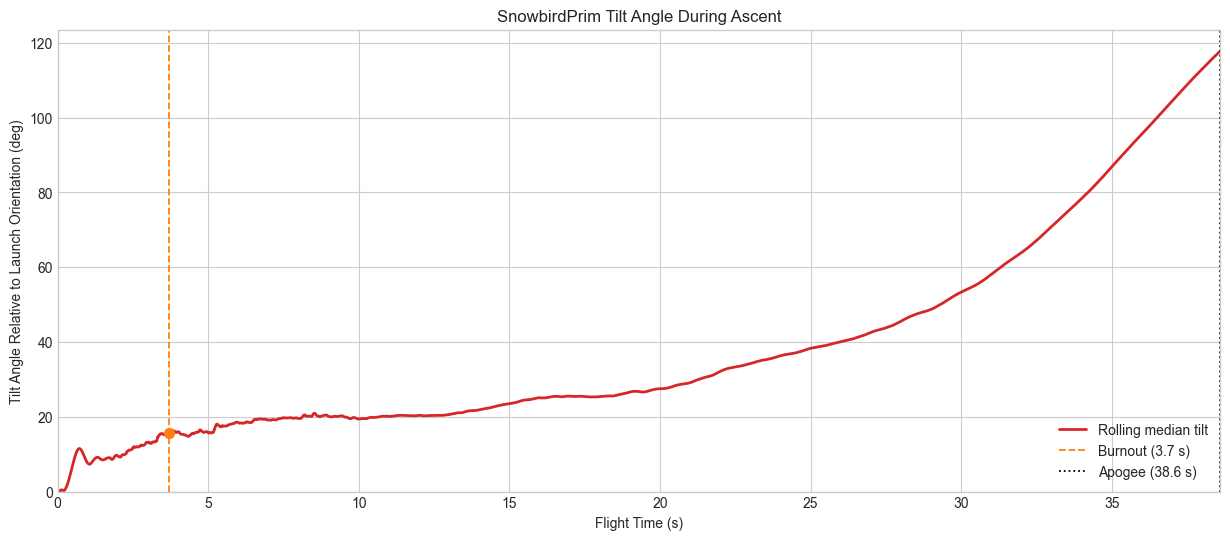

In [43]:
plot_df = ascent.copy()
plot_df["tilt_angle_smooth_deg"] = (
    plot_df["tilt_angle_deg"]
    .rolling(window=25, center=True, min_periods=1)
    .median()
)

fig, ax = plt.subplots(figsize=(15, 6))
# ax.plot(
#     plot_df["Flight_Time_(s)"],
#     plot_df["tilt_angle_deg"],
#     color="tab:blue",
#     linewidth=1.0,
#     alpha=0.45,
#     label="Instantaneous tilt",
# )
ax.plot(
    plot_df["Flight_Time_(s)"],
    plot_df["tilt_angle_smooth_deg"],
    color="tab:red",
    linewidth=2.0,
    label="Rolling median tilt",
)

ax.axvline(burnout_time_s, color="tab:orange", linestyle="--", linewidth=1.3, label=f"Burnout ({burnout_time_s:.1f} s)")
ax.axvline(apogee_time_s, color="black", linestyle=":", linewidth=1.3, label=f"Apogee ({apogee_time_s:.1f} s)")
ax.scatter(
    [burnout_time_s],
    [computed_burnout_tilt_deg],
    color="tab:orange",
    s=50,
    zorder=5,
)

ax.set_title("SnowbirdPrim Tilt Angle During Ascent")
ax.set_xlabel("Flight Time (s)")
ax.set_ylabel("Tilt Angle Relative to Launch Orientation (deg)")
ax.set_xlim(0.0, apogee_time_s)
ax.set_ylim(bottom=0.0)
ax.legend()
plt.show()

In [44]:
peak_tilt_row = plot_df.loc[plot_df["tilt_angle_deg"].idxmax(), ["Flight_Time_(s)", "tilt_angle_deg"]]
peak_tilt_row

Flight_Time_(s)     38.582
tilt_angle_deg     117.642
Name: 19291, dtype: object

## Coning Diagnostic in the Global Frame

Tilt magnitude alone does not show whether the rocket axis is precessing around the nominal flight direction. This section keeps the same quaternion-based rocket axis vector, but now tracks its direction in a fixed global frame.

Approach:
- Express the rocket body `+X` axis in the global frame at each ascent sample.
- Project that axis onto the plane normal to the launch axis.
- Measure the transverse direction angle in that plane.

If the rocket is strongly coning, the tip of the axis should make clear loops in that transverse plane. If the tip mostly drifts in one direction, then the rocket is tilting away from the launch axis without sustained coning.

In [45]:
def build_plane_basis(axis: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)

    seed = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(seed, axis)) > 0.95:
        seed = np.array([0.0, 1.0, 0.0])

    basis_u = seed - np.dot(seed, axis) * axis
    basis_u = basis_u / np.linalg.norm(basis_u)
    basis_v = np.cross(axis, basis_u)
    basis_v = basis_v / np.linalg.norm(basis_v)
    return basis_u, basis_v


ascent_mask = flight["Flight_Time_(s)"].to_numpy() <= apogee_time_s
ascent_axis_vectors = rocket_axis_vectors[ascent_mask]
basis_u, basis_v = build_plane_basis(launch_axis)

transverse_u = ascent_axis_vectors @ basis_u
transverse_v = ascent_axis_vectors @ basis_v
parallel_component = ascent_axis_vectors @ launch_axis
coning_phase_rad = np.unwrap(np.arctan2(transverse_v, transverse_u))

coning_df = ascent[["Flight_Time_(s)", "tilt_angle_deg"]].copy()
coning_df[["axis_global_x", "axis_global_y", "axis_global_z"]] = ascent_axis_vectors
coning_df["global_azimuth_deg"] = np.degrees(np.unwrap(np.arctan2(coning_df["axis_global_y"], coning_df["axis_global_x"])))
coning_df["global_elevation_deg"] = np.degrees(
    np.arctan2(coning_df["axis_global_z"], np.sqrt(coning_df["axis_global_x"] ** 2 + coning_df["axis_global_y"] ** 2))
)
coning_df["tilt_u_deg"] = coning_df["tilt_angle_deg"] * np.cos(coning_phase_rad)
coning_df["tilt_v_deg"] = coning_df["tilt_angle_deg"] * np.sin(coning_phase_rad)
coning_df["coning_phase_deg"] = np.degrees(coning_phase_rad)

smooth_window = 101
for column in [
    "axis_global_x",
    "axis_global_y",
    "axis_global_z",
    "global_azimuth_deg",
    "global_elevation_deg",
    "tilt_u_deg",
    "tilt_v_deg",
    "coning_phase_deg",
]:
    coning_df[f"{column}_smooth"] = coning_df[column].rolling(
        window=smooth_window, center=True, min_periods=1
    ).mean()

phase_valid_mask = (coning_df["tilt_angle_deg"] >= 5.0) & (coning_df["tilt_angle_deg"] <= 60.0)
phase_change_deg = float(
    coning_df.loc[phase_valid_mask, "coning_phase_deg_smooth"].iloc[-1]
    - coning_df.loc[phase_valid_mask, "coning_phase_deg_smooth"].iloc[0]
)
signed_revolutions = phase_change_deg / 360.0
absolute_revolutions = float(
    np.abs(np.diff(coning_df.loc[phase_valid_mask, "coning_phase_deg_smooth"])).sum() / 360.0
)

if absolute_revolutions >= 0.75 and abs(signed_revolutions) >= 0.25:
    coning_assessment = "Clear coning is plausible in the small-to-moderate tilt regime."
elif absolute_revolutions >= 0.25:
    coning_assessment = "Some directional wobble is present, but the ascent is dominated by steady pitching rather than full coning."
else:
    coning_assessment = "Little evidence of sustained coning appears before the large end-of-ascent tip-over."

coning_summary = pd.DataFrame(
    [
        {"metric": "Phase analysis window start (tilt >= 5 deg) (s)", "value": float(coning_df.loc[phase_valid_mask, "Flight_Time_(s)"].iloc[0])},
        {"metric": "Phase analysis window end (tilt <= 60 deg) (s)", "value": float(coning_df.loc[phase_valid_mask, "Flight_Time_(s)"].iloc[-1])},
        {"metric": "Phase change in launch-normal plane (deg)", "value": phase_change_deg},
        {"metric": "Signed revolutions in analysis window", "value": signed_revolutions},
        {"metric": "Absolute revolutions in analysis window", "value": absolute_revolutions},
        {"metric": "Global azimuth change in analysis window (deg)", "value": float(coning_df.loc[phase_valid_mask, "global_azimuth_deg_smooth"].iloc[-1] - coning_df.loc[phase_valid_mask, "global_azimuth_deg_smooth"].iloc[0])},
        {"metric": "Global elevation change in analysis window (deg)", "value": float(coning_df.loc[phase_valid_mask, "global_elevation_deg_smooth"].iloc[-1] - coning_df.loc[phase_valid_mask, "global_elevation_deg_smooth"].iloc[0])},
        {"metric": "Assessment", "value": coning_assessment},
    ]
)

coning_summary

,metric,value
0,Phase analysis window start (tilt >= 5 deg) (s),0.434
1,Phase analysis window end (tilt <= 60 deg) (s),31.308
2,Phase change in launch-normal plane (deg),6.056
3,Signed revolutions in analysis window,0.017
4,Absolute revolutions in analysis window,0.323
5,Global azimuth change in analysis window (deg),-2.764
6,Global elevation change in analysis window (deg),-54.879
7,Assessment,"Some directional wobble is present, but the as..."


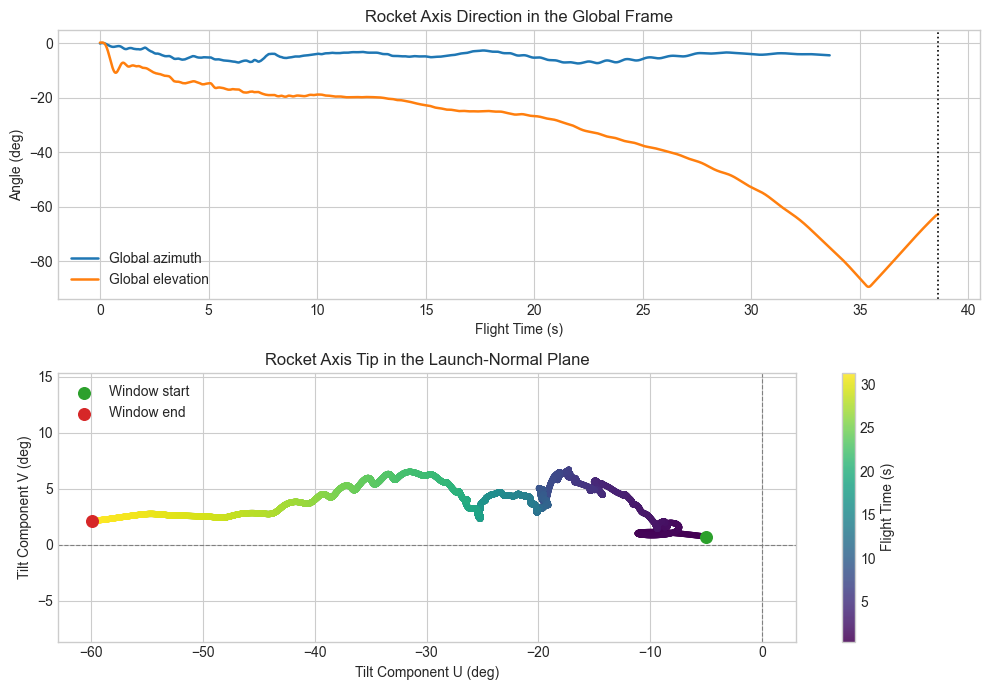

Some directional wobble is present, but the ascent is dominated by steady pitching rather than full coning.


In [62]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

time_s = coning_df["Flight_Time_(s)"]

# One-way mask for azimuth: once elevation enters the polar-singularity region,
# keep azimuth hidden for all subsequent times.
az_plot = coning_df["global_azimuth_deg_smooth"].copy()
elev_abs = np.abs(coning_df["global_elevation_deg_smooth"].to_numpy())
singularity_indices = np.where(elev_abs > 75.0)[0]
if len(singularity_indices) > 0:
    first_singularity_idx = int(singularity_indices[0])
    az_plot.iloc[first_singularity_idx:] = np.nan

axes[0].plot(time_s, az_plot, label="Global azimuth", linewidth=1.8)
axes[0].plot(time_s, coning_df["global_elevation_deg_smooth"], label="Global elevation", linewidth=1.8)
axes[0].axvline(apogee_time_s, color="black", linestyle=":", linewidth=1.2)
axes[0].set_title("Rocket Axis Direction in the Global Frame")
axes[0].set_xlabel("Flight Time (s)")
axes[0].set_ylabel("Angle (deg)")
axes[0].legend()

scatter = axes[1].scatter(
    coning_df.loc[phase_valid_mask, "tilt_u_deg_smooth"],
    coning_df.loc[phase_valid_mask, "tilt_v_deg_smooth"],
    c=coning_df.loc[phase_valid_mask, "Flight_Time_(s)"],
    cmap="viridis",
    s=12,
    alpha=0.85,
)
axes[1].scatter(
    coning_df.loc[phase_valid_mask, "tilt_u_deg_smooth"].iloc[0],
    coning_df.loc[phase_valid_mask, "tilt_v_deg_smooth"].iloc[0],
    color="tab:green",
    s=70,
    label="Window start",
)
axes[1].scatter(
    coning_df.loc[phase_valid_mask, "tilt_u_deg_smooth"].iloc[-1],
    coning_df.loc[phase_valid_mask, "tilt_v_deg_smooth"].iloc[-1],
    color="tab:red",
    s=70,
    label="Window end",
)
axes[1].axhline(0.0, color="grey", linewidth=0.8, linestyle="--")
axes[1].axvline(0.0, color="grey", linewidth=0.8, linestyle="--")
axes[1].set_title("Rocket Axis Tip in the Launch-Normal Plane")
axes[1].set_xlabel("Tilt Component U (deg)")
axes[1].set_ylabel("Tilt Component V (deg)")
axes[1].axis("equal")
axes[1].legend()
fig.colorbar(scatter, ax=axes[1], label="Flight Time (s)")

# axes[2].plot(time_s, coning_df["coning_phase_deg_smooth"], color="tab:purple", linewidth=1.8)
# axes[2].axvspan(
#     coning_df.loc[phase_valid_mask, "Flight_Time_(s)"].iloc[0],
#     coning_df.loc[phase_valid_mask, "Flight_Time_(s)"].iloc[-1],
#     color="tab:orange",
#     alpha=0.12,
#     label="Coning analysis window",
# )
# axes[2].axvline(apogee_time_s, color="black", linestyle=":", linewidth=1.2, label=f"Apogee ({apogee_time_s:.1f} s)")
# axes[2].set_title("Direction of Tilt Around the Launch Axis")
# axes[2].set_xlabel("Flight Time (s)")
# axes[2].set_ylabel("Coning Phase (deg, unwrapped)")
# axes[2].legend()

fig.tight_layout()
plt.show()

print(coning_assessment)

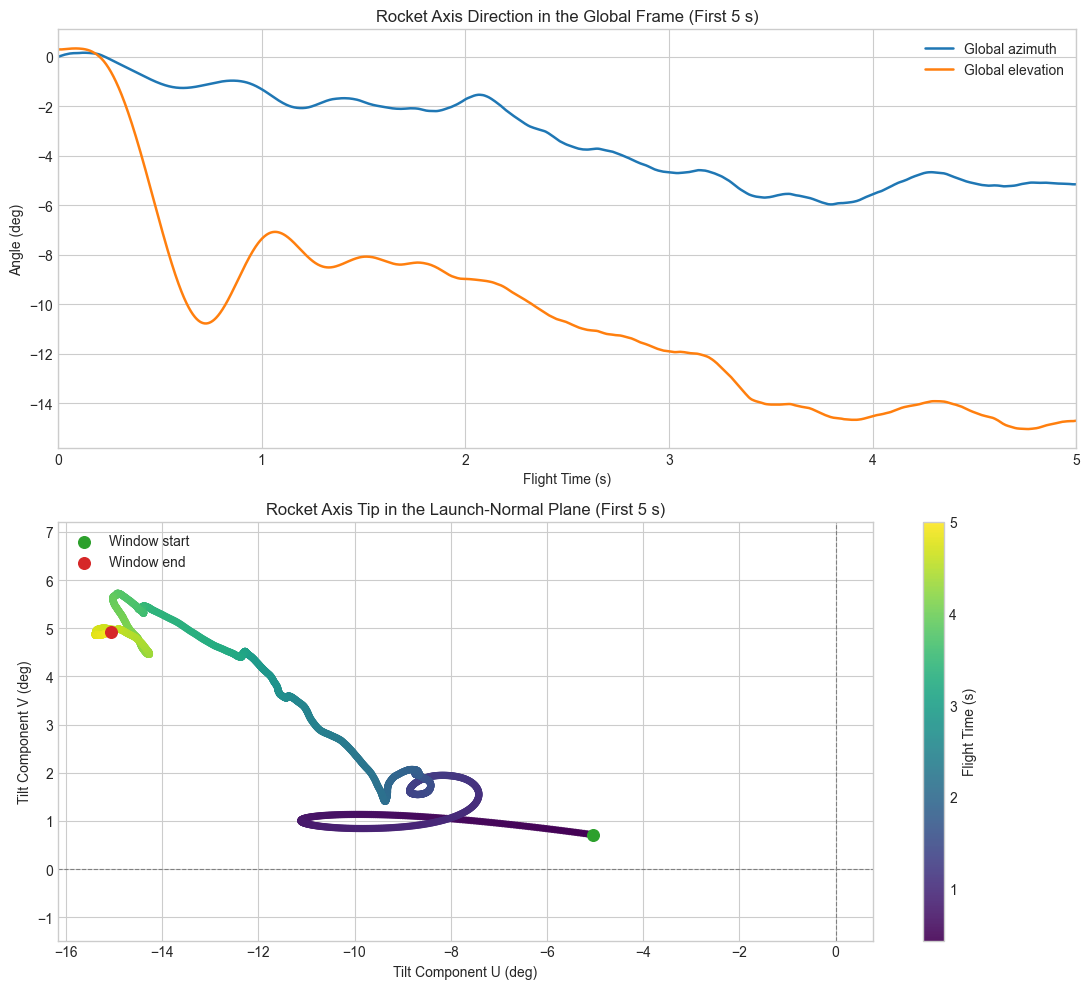

In [63]:
zoom_end_s = 5.0
zoom_mask = coning_df["Flight_Time_(s)"] <= zoom_end_s
zoom_phase_mask = phase_valid_mask & zoom_mask

fig, axes = plt.subplots(2, 1, figsize=(11, 10))

time_zoom = coning_df.loc[zoom_mask, "Flight_Time_(s)"]

# Keep the same one-way azimuth masking behavior, then zoom to first 5 s.
az_plot_zoom = coning_df["global_azimuth_deg_smooth"].copy()
elev_abs = np.abs(coning_df["global_elevation_deg_smooth"].to_numpy())
singularity_indices = np.where(elev_abs > 75.0)[0]
if len(singularity_indices) > 0:
    first_singularity_idx = int(singularity_indices[0])
    az_plot_zoom.iloc[first_singularity_idx:] = np.nan

axes[0].plot(time_zoom, az_plot_zoom.loc[zoom_mask], label="Global azimuth", linewidth=1.8)
axes[0].plot(time_zoom, coning_df.loc[zoom_mask, "global_elevation_deg_smooth"], label="Global elevation", linewidth=1.8)
axes[0].axvline(apogee_time_s, color="black", linestyle=":", linewidth=1.2)
axes[0].set_xlim(0.0, zoom_end_s)
axes[0].set_title("Rocket Axis Direction in the Global Frame (First 5 s)")
axes[0].set_xlabel("Flight Time (s)")
axes[0].set_ylabel("Angle (deg)")
axes[0].legend()

if zoom_phase_mask.any():
    scatter = axes[1].scatter(
        coning_df.loc[zoom_phase_mask, "tilt_u_deg_smooth"],
        coning_df.loc[zoom_phase_mask, "tilt_v_deg_smooth"],
        c=coning_df.loc[zoom_phase_mask, "Flight_Time_(s)"],
        cmap="viridis",
        s=18,
        alpha=0.9,
    )
    axes[1].scatter(
        coning_df.loc[zoom_phase_mask, "tilt_u_deg_smooth"].iloc[0],
        coning_df.loc[zoom_phase_mask, "tilt_v_deg_smooth"].iloc[0],
        color="tab:green",
        s=70,
        label="Window start",
    )
    axes[1].scatter(
        coning_df.loc[zoom_phase_mask, "tilt_u_deg_smooth"].iloc[-1],
        coning_df.loc[zoom_phase_mask, "tilt_v_deg_smooth"].iloc[-1],
        color="tab:red",
        s=70,
        label="Window end",
    )
    fig.colorbar(scatter, ax=axes[1], label="Flight Time (s)")
else:
    axes[1].text(0.5, 0.5, "No coning-window samples within first 5 s", ha="center", va="center", transform=axes[1].transAxes)

axes[1].axhline(0.0, color="grey", linewidth=0.8, linestyle="--")
axes[1].axvline(0.0, color="grey", linewidth=0.8, linestyle="--")
axes[1].set_title("Rocket Axis Tip in the Launch-Normal Plane (First 5 s)")
axes[1].set_xlabel("Tilt Component U (deg)")
axes[1].set_ylabel("Tilt Component V (deg)")
axes[1].axis("equal")
axes[1].legend()

# axes[2].plot(coning_df.loc[zoom_mask, "Flight_Time_(s)"], coning_df.loc[zoom_mask, "coning_phase_deg_smooth"], color="tab:purple", linewidth=1.8)
# if zoom_phase_mask.any():
#     axes[2].axvspan(
#         float(coning_df.loc[zoom_phase_mask, "Flight_Time_(s)"].iloc[0]),
#         float(coning_df.loc[zoom_phase_mask, "Flight_Time_(s)"].iloc[-1]),
#         color="tab:orange",
#         alpha=0.12,
#         label="Coning analysis window",
#     )
# axes[2].axvline(apogee_time_s, color="black", linestyle=":", linewidth=1.2, label=f"Apogee ({apogee_time_s:.1f} s)")
# axes[2].set_xlim(0.0, zoom_end_s)
# axes[2].set_title("Direction of Tilt Around the Launch Axis (First 5 s)")
# axes[2].set_xlabel("Flight Time (s)")
# axes[2].set_ylabel("Coning Phase (deg, unwrapped)")
# axes[2].legend()

fig.tight_layout()
plt.show()